In [1]:
import tensorflow as tf
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from keras.models import Sequential
from keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from sklearn.metrics import classification_report, confusion_matrix
import cv2
import seaborn as sns

from pathlib import Path

import collections




Model Preprocessing

In [3]:
# Define Dataset Paths
train_dir = '/Users/michaelperrine/Library/CloudStorage/OneDrive-Personal/Documents/Bellevue/Applied Data Science/Project 3/archive/train'
val_dir = '/Users/michaelperrine/Library/CloudStorage/OneDrive-Personal/Documents/Bellevue/Applied Data Science/Project 3/archive/val'
test_dir = '/Users/michaelperrine/Library/CloudStorage/OneDrive-Personal/Documents/Bellevue/Applied Data Science/Project 3/archive/test'

In [4]:
# Coit Images in Each Class
count_normal = len(os.listdir(os.path.join(train_dir, 'normal')))
count_pneumonia = len(os.listdir(os.path.join(train_dir, 'pneumonia')))
count_tuberulosis = len(os.listdir(os.path.join(train_dir, 'tuberculosis')))

In [5]:
# Print Counts
print(f"Number of normal images in training set: {count_normal}")
print(f"Number of pneumonia images in training set: {count_pneumonia}")
print(f"Number of tuberulosis images in training set: {count_tuberulosis}")

Number of normal images in training set: 7263
Number of pneumonia images in training set: 4674
Number of tuberulosis images in training set: 8513


In [6]:
# Define Image Parameters
image_height = 224
image_width = 224
batch_size = 10


In [7]:
# Load Datasets
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    color_mode = 'grayscale',
    image_size = (image_height, image_width),
    batch_size = batch_size
)
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    val_dir,
    color_mode = 'grayscale',
    image_size = (image_height, image_width),
    batch_size = batch_size
)
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    color_mode = 'grayscale',
    image_size = (image_height, image_width),
    batch_size = batch_size
)

Found 20450 files belonging to 3 classes.
Found 2534 files belonging to 3 classes.
Found 2569 files belonging to 3 classes.


2025-11-18 08:31:13.961528: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Pro
2025-11-18 08:31:13.961559: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 48.00 GB
2025-11-18 08:31:13.961562: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 18.00 GB
2025-11-18 08:31:13.961579: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-11-18 08:31:13.961588: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [8]:
# Get Class Names
train_ds.class_names

['normal', 'pneumonia', 'tuberculosis']

2025-11-18 08:31:14.241365: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


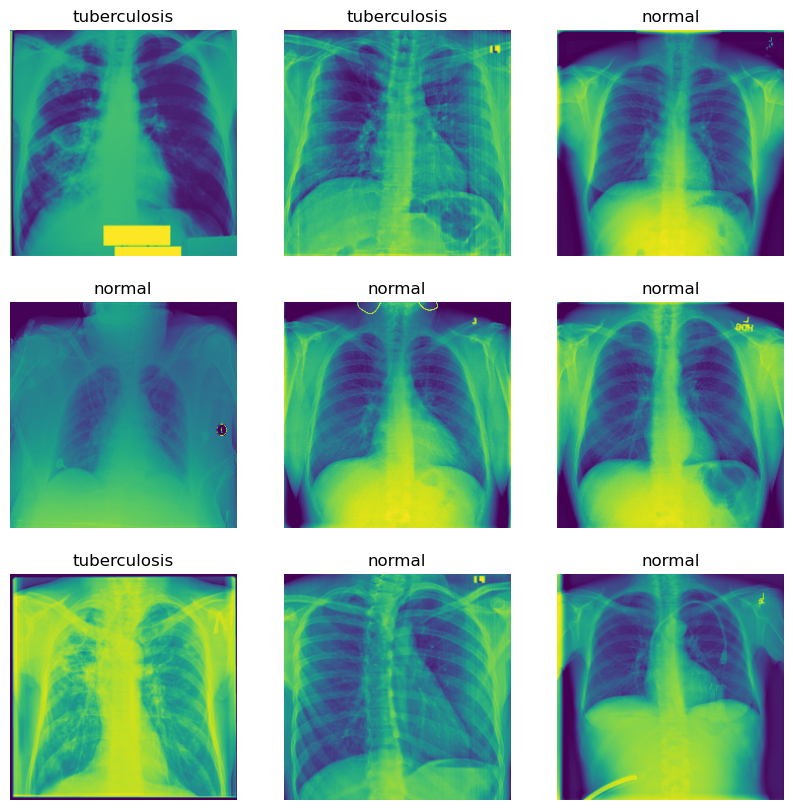

In [9]:
# Visualize Sample Images
plt.figure(figsize=(10,10))
for images, labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(np.squeeze(images[i].numpy().astype('uint8')))
        plt.title(train_ds.class_names[labels[i]])
        plt.axis('off')

In [10]:
# Optimize Dataset Performance
autotune = tf.data. experimental.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size = autotune)
val_ds = val_ds.cache().prefetch(buffer_size = autotune)
test_ds = test_ds.cache().prefetch(buffer_size = autotune)

In [11]:
# Build the Model
model = tf.keras.Sequential([
   tf.keras.layers.Rescaling(1./255), 
    tf.keras.layers.Conv2D(32, 3, activation = 'relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(32, 3, activation = 'relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(32, 3, activation = 'relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation = 'relu'),
    tf.keras.layers.Dense(3, activation = 'softmax')
])

In [12]:
# Compile the Model
model.compile(optimizer = 'Adam',
              loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics = ['accuracy'])

In [13]:
# Train the Model
epochs = 10

In [14]:
# Fit the Model
model.fit(
    train_ds,
    validation_data = val_ds,
    epochs = epochs
)

Epoch 1/10


/opt/anaconda3/envs/tf/lib/python3.10/site-packages/keras/src/backend/tensorflow/nn.py:717: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(
2025-11-18 08:31:14.696644: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


2045/2045 ━━━━━━━━━━━━━━━━━━━━ 37s 15ms/step - accuracy: 0.6551 - loss: 0.9016 - val_accuracy: 0.6796 - val_loss: 0.8385
Epoch 2/10
2045/2045 ━━━━━━━━━━━━━━━━━━━━ 29s 14ms/step - accuracy: 0.6687 - loss: 1.3940 - val_accuracy: 0.6381 - val_loss: 1.6341
Epoch 3/10
2045/2045 ━━━━━━━━━━━━━━━━━━━━ 29s 14ms/step - accuracy: 0.6537 - loss: 3.6252 - val_accuracy: 0.6456 - val_loss: 3.8298
Epoch 4/10
2045/2045 ━━━━━━━━━━━━━━━━━━━━ 29s 14ms/step - accuracy: 0.6621 - loss: 10.6888 - val_accuracy: 0.6310 - val_loss: 15.7143
Epoch 5/10
2045/2045 ━━━━━━━━━━━━━━━━━━━━ 29s 14ms/step - accuracy: 0.6648 - loss: 50.5466 - val_accuracy: 0.6468 - val_loss: 62.7321
Epoch 6/10
2045/2045 ━━━━━━━━━━━━━━━━━━━━ 29s 14ms/step - accuracy: 0.6601 - loss: 257.3127 - val_accuracy: 0.6618 - val_loss: 265.7288
Epoch 7/10
2045/2045 ━━━━━━━━━━━━━━━━━━━━ 29s 14ms/step - accuracy: 0.6622 - loss: 809.6078 - val_accuracy: 0.6500 - val_loss: 1776.5756
Epoch 8/10
2045/2045 ━━━━━━━━━━━━━━━━━━━━ 29s 14ms/step - accuracy: 0.6667

In [15]:
# Evaluate the Model
model.evaluate(test_ds)

257/257 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6746 - loss: 5361.3428


[5361.3427734375, 0.6745815277099609]

In [16]:
model.save('xray model0.keras')